<a href="https://colab.research.google.com/github/shruti63-code/stock_price_prediction/blob/main/Stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!pip install yfinance ta statsmodels prophet tensorflow --quiet

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [31]:
ticker = "AAPL"

data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data.reset_index(inplace=True)

data.head()

/tmp/ipykernel_302/1925597542.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
1,2015-01-05,23.532726,24.064289,23.346680,23.984555,257142000
2,2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
3,2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


In [32]:
data["SMA"] = ta.trend.sma_indicator(data["Close"].squeeze(), window=14)
data["EMA"] = ta.trend.ema_indicator(data["Close"].squeeze(), window=14)
data["RSI"] = ta.momentum.rsi(data["Close"].squeeze(), window=14)
data["MACD"] = ta.trend.macd(data["Close"].squeeze())

data.dropna(inplace=True)
data.head()

Price,Date,Close,High,Low,Open,Volume,SMA,EMA,RSI,MACD
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
25,2015-02-09,26.620762,26.647444,26.333919,26.360603,155559200,25.714107,25.829679,66.460266,0.632552
26,2015-02-10,27.132181,27.161089,26.718596,26.720818,248034000,25.919004,26.003346,70.229419,0.679774
27,2015-02-11,27.768135,27.777030,27.238922,27.298958,294247200,26.124239,26.238651,74.123640,0.759756
28,2015-02-12,28.119465,28.346272,27.921566,28.030521,297898000,26.345393,26.489426,75.992011,0.841788
29,2015-02-13,28.257322,28.301793,27.939350,28.301793,217088800,26.574495,26.725146,76.702836,0.907463


In [33]:
arima_model = ARIMA(data["Close"], order=(5,1,0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=30)

print("ARIMA Forecast:")
print(arima_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA Forecast:
2239    190.537132
2240    190.535101
2241    190.551053
2242    190.570843
2243    190.528609
2244    190.528989
2245    190.529599
2246    190.530665
2247    190.531524
2248    190.529784
2249    190.529828
2250    190.529878
2251    190.529936
2252    190.529972
2253    190.529900
2254    190.529902
2255    190.529905
2256    190.529908
2257    190.529910
2258    190.529907
2259    190.529907
2260    190.529907
2261    190.529907
2262    190.529907
2263    190.529907
2264    190.529907
2265    190.529907
2266    190.529907
2267    190.529907
2268    190.529907
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


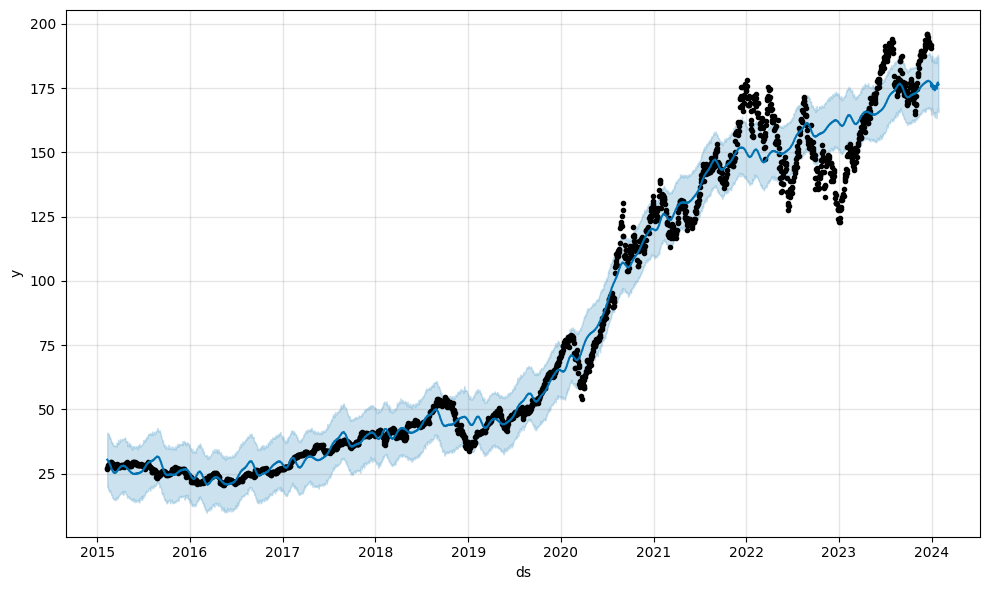

In [34]:
prophet_df = data[["Date", "Close"]]
prophet_df.columns = ["ds", "y"]

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)

prophet_model.plot(forecast)
plt.show()

In [35]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data["Close"].values.reshape(-1,1))

In [36]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

In [37]:
model = Sequential()
model.add(LSTM(50, input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.0364
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 5.1794e-04
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 6.6710e-04
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 4.4764e-04
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 4.2975e-04


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


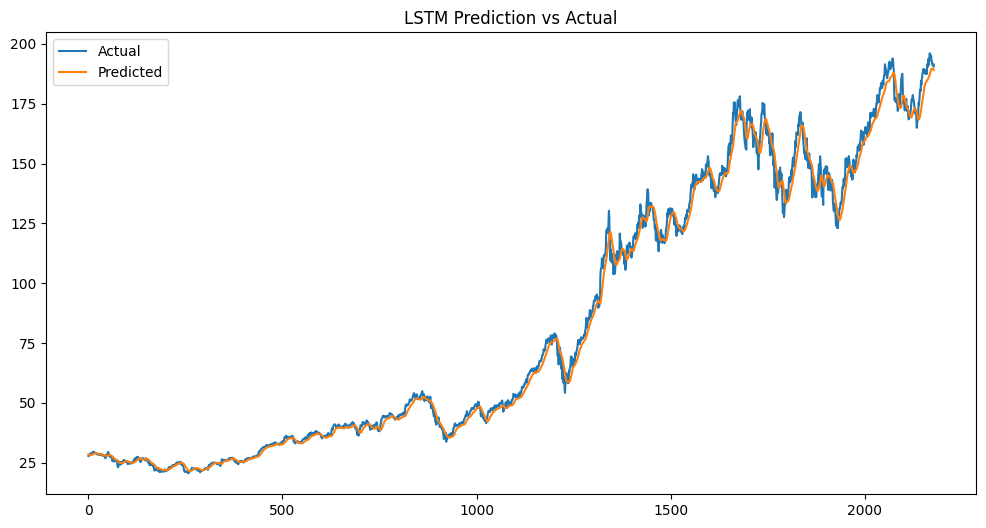

In [38]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

actual = data["Close"].values[60:]

plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()

In [39]:
data_lstm = data.iloc[60:].copy()
data_lstm["Predicted"] = predictions.flatten()


data_lstm['Close'] = data_lstm['Close'].squeeze()
data_lstm['RSI'] = data_lstm['RSI'].squeeze()

signals = []

for i in range(len(data_lstm)):
    predicted_val = data_lstm["Predicted"].iloc[i]
    close_val = data_lstm["Close"].iloc[i]
    rsi_val = data_lstm["RSI"].iloc[i]


    if isinstance(predicted_val, pd.Series): predicted_val = predicted_val.item()
    if isinstance(close_val, pd.Series): close_val = close_val.item()
    if isinstance(rsi_val, pd.Series): rsi_val = rsi_val.item()

    if predicted_val > close_val and rsi_val < 30:
        signals.append("BUY")
    elif predicted_val < close_val and rsi_val > 70:
        signals.append("SELL")
    else:
        signals.append("HOLD")

data_lstm["Signal"] = signals
data_lstm.head()

Price,Date,Close,High,Low,Open,Volume,SMA,EMA,RSI,MACD,Predicted,Signal
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,
85,2015-05-06,27.797047,28.183950,27.430155,28.141701,288564000,28.482383,28.356029,44.824473,0.063082,28.440805,HOLD
86,2015-05-07,27.968979,28.152074,27.692101,27.859567,175763600,28.498794,28.304422,46.785182,0.027824,28.374802,HOLD
87,2015-05-08,28.495932,28.495932,28.158767,28.286041,222201600,28.507579,28.329957,52.371581,0.041918,28.304674,HOLD
88,2015-05-11,28.205664,28.482540,28.051595,28.444581,168143200,28.506589,28.313384,49.301355,0.029328,28.267931,HOLD
89,2015-05-12,28.105185,28.330704,27.870732,28.044896,192640000,28.471262,28.285624,48.246954,0.011115,28.236256,HOLD


In [40]:
initial_balance = 10000
balance = initial_balance
shares = 0

for i in range(len(data_lstm)):
    price = data_lstm["Close"].iloc[i].item()
    signal = data_lstm["Signal"].iloc[i]

    if signal == "BUY" and balance > 0:
        shares = balance / price
        balance = 0

    elif signal == "SELL" and shares > 0:
        balance = shares * price
        shares = 0

final_value = balance + shares * data_lstm["Close"].iloc[-1].item()

print("Initial Balance:", initial_balance)
print("Final Portfolio Value:", final_value)
print("Total Return %:", ((final_value-initial_balance)/initial_balance)*100)

Initial Balance: 10000
Final Portfolio Value: 29077.839057072782
Total Return %: 190.77839057072782


In [41]:
rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3.8085507323110757
MAE: 2.6570492421010594


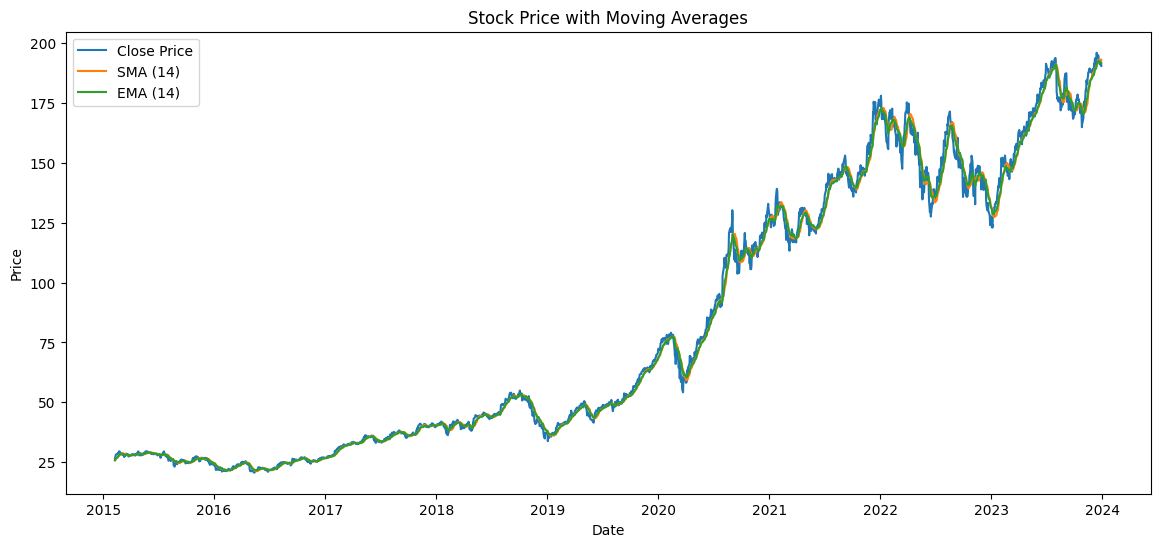

In [42]:
plt.figure(figsize=(14,6))
plt.plot(data["Date"], data["Close"], label="Close Price")
plt.plot(data["Date"], data["SMA"], label="SMA (14)")
plt.plot(data["Date"], data["EMA"], label="EMA (14)")

plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

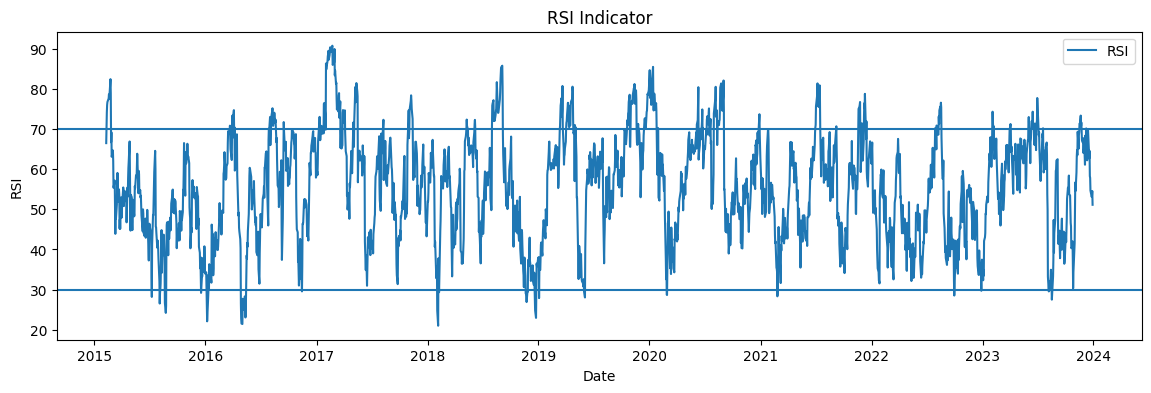

In [43]:
plt.figure(figsize=(14,4))
plt.plot(data["Date"], data["RSI"], label="RSI")
plt.axhline(70)
plt.axhline(30)

plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()

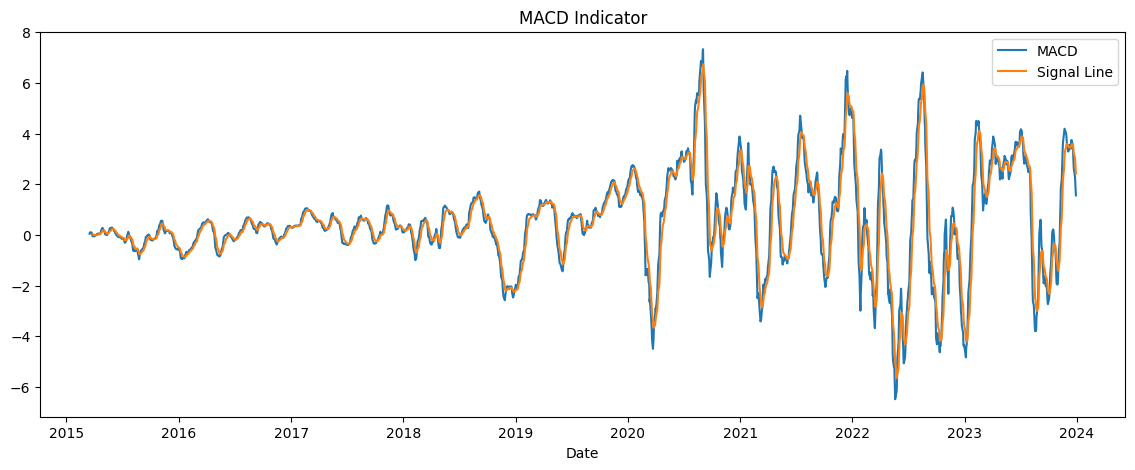

In [44]:
macd_line = ta.trend.macd(data["Close"].squeeze())
macd_signal = ta.trend.macd_signal(data["Close"].squeeze())

plt.figure(figsize=(14,5))
plt.plot(data["Date"], macd_line, label="MACD")
plt.plot(data["Date"], macd_signal, label="Signal Line")

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.legend()
plt.show()

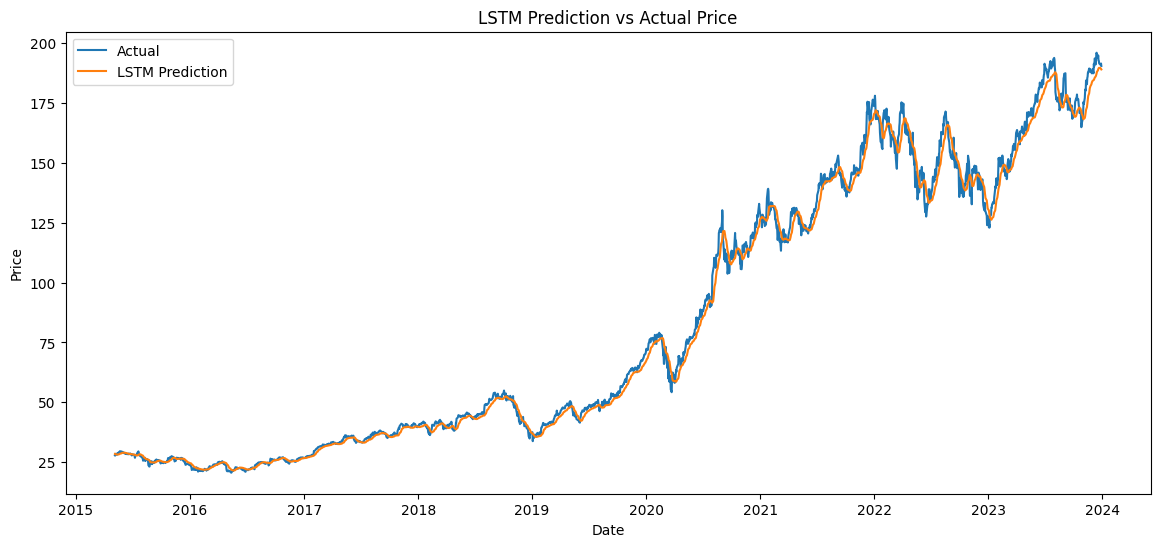

In [45]:
plt.figure(figsize=(14,6))
plt.plot(data_lstm["Date"], data_lstm["Close"], label="Actual")
plt.plot(data_lstm["Date"], data_lstm["Predicted"], label="LSTM Prediction")

plt.title("LSTM Prediction vs Actual Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

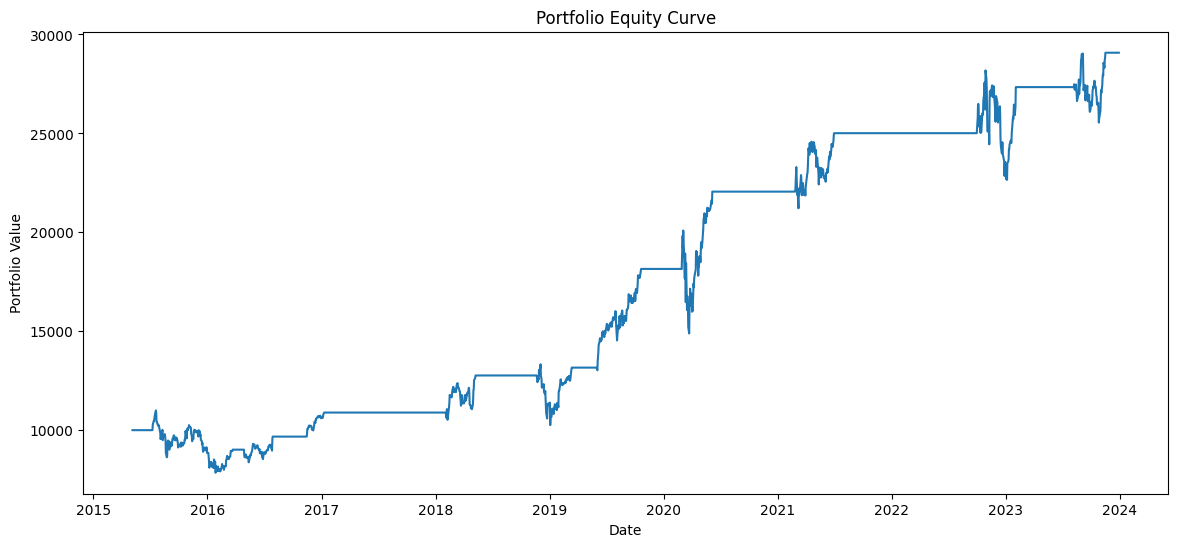

In [46]:
portfolio_values = []
balance = 10000
shares = 0

for i in range(len(data_lstm)):
    price = data_lstm["Close"].iloc[i].item() # Convert price to a scalar
    signal = data_lstm["Signal"].iloc[i]

    if signal == "BUY" and balance > 0:
        shares = balance / price
        balance = 0

    elif signal == "SELL" and shares > 0:
        balance = shares * price
        shares = 0

    portfolio_values.append(balance + shares * price)

plt.figure(figsize=(14,6))
plt.plot(data_lstm["Date"], portfolio_values)
plt.title("Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

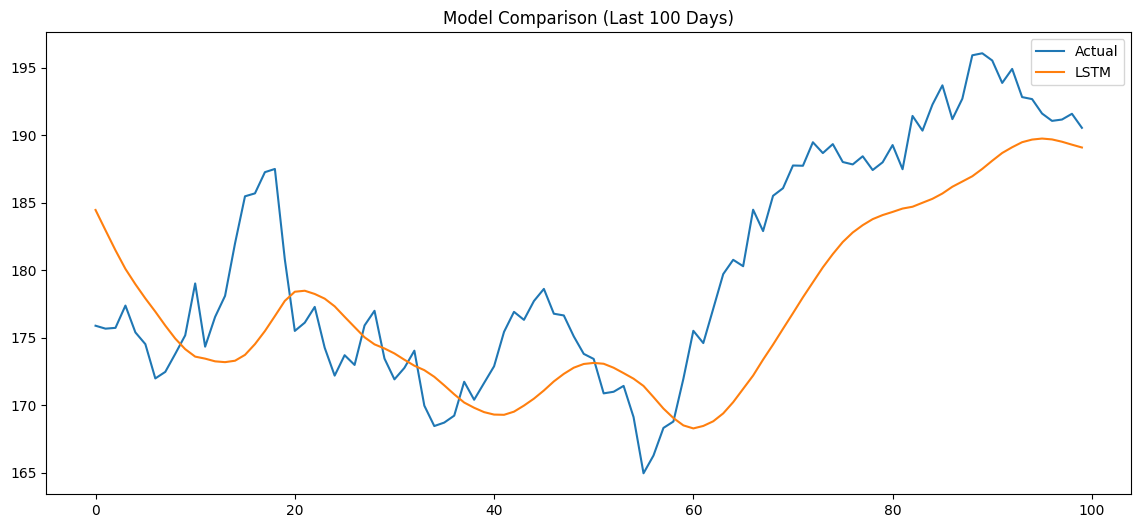

In [47]:
plt.figure(figsize=(14,6))

plt.plot(actual[-100:], label="Actual")
plt.plot(predictions[-100:], label="LSTM")

plt.title("Model Comparison (Last 100 Days)")
plt.legend()
plt.show()